# ssGSEA-based Enrichment Analysis on TCGA Data

In this analysis, I apply **Single-Sample Gene Set Enrichment Analysis (ssGSEA)** to 
bulk RNA-seq data from **The Cancer Genome Atlas (TCGA)** across multiple tumor types. 
The goal is to quantify, at the sample level, the transcriptional activity of 
7 hormones-related gene sets (curated from MSigDB), enabling comparison 
of hormone pathway activity across cancer types.

**Key methodological choices:**
- TPM-normalized expression data to ensure comparability across samples
- Log-transformation to reduce dynamic range and approximate normality
- ssGSEA (via GSVA) without score normalization, to preserve cross-sample comparability
- Duplicate gene names resolved by appending Ensembl gene IDs

This workflow is generalizable to any gene set of interest and any cohort with 
bulk transcriptomic data.

## 1. Library Loading

We load the core libraries for this analysis:
- **GSVA** for ssGSEA computation
- **tidyverse** for data wrangling
- **ComplexHeatmap + circlize** for visualization
- **data.table + matrixStats** for efficient matrix operations

All libraries are available via Bioconductor and CRAN.

In [9]:
library(GSVA)
library(tidyverse)
library(matrixStats)
library(circlize)
library(ComplexHeatmap)
library(data.table)


## 2. TCGA Pan-Cancer Metadata

We start by loading the TCGA cancer type metadata, which maps each cancer acronym 
(e.g., `COAD`, `BRCA`, `LUAD`) to patient counts. This table drives the downstream 
loop over available tumor cohorts and ensures the analysis scales cleanly to all 
tumor types without hardcoding.

Inspecting the first rows confirms the structure before we proceed.

In [10]:
# ── Load cancer metadata ───────────────────────────────────────────────────
cancer_df=read.csv('data/PANCANCER_acronym_npatients.tsv', sep='\t')
cancers<-c(cancer_df$Cancer_acronym)
head(cancer_df)

,Cancer_acronym,N_of_patients
,<chr>,<int>
1,UCEC,537
2,CHOL,36
3,TGCT,133
4,PAAD,177
5,GBM,143
6,SKCM,103


## 3. Gene Name Deduplication

A common issue in RNA-seq count matrices is **duplicate gene names** arising from 
pseudogenes, paralogs, or alternative transcripts sharing the same gene symbol. 
Downstream tools like ssGSEA require unique row identifiers.

Here we resolve duplicates by appending the Ensembl gene ID to any gene name 
that appears more than once. This is preferable to simply dropping duplicates, 
as it retains all expression information while ensuring row uniqueness.

This deduplication strategy is a reusable pattern applicable to any bulk 
RNA-seq preprocessing pipeline.

In [11]:
# ── Build deduplicated gene name vector from reference sample ──────────────
# We use TCGA-COAD as the reference to build a unique gene name index,
# assuming all cohorts share the same gene annotation.

ref_tumor   <- "TCGA-COAD"
counts_ref  <- read.csv(
  paste0("data/TPM/NO_outlier/", ref_tumor, "_2025_TumorSamples&NATSamples_TPM_No_outlier.tsv"),
  sep = "\t"
)

head(counts_ref)
nrow(counts_ref)

,gene_id,gene_name,TCGA.AA.3688.01A,TCGA.G4.6298.01A,TCGA.AA.3672.01A,TCGA.G4.6314.01A,TCGA.A6.2682.01A,TCGA.AA.3562.01A,TCGA.AA.3979.01A,TCGA.AA.3524.01A,⋯,TCGA.AA.3489.01A,TCGA.AA.3968.01A,TCGA.F4.6806.01A,TCGA.CM.6678.01A,TCGA.AZ.4682.01B,TCGA.DM.A1DB.01A,TCGA.AA.3534.01A,TCGA.AY.A54L.01A,TCGA.D5.6530.01A,TCGA.DM.A1D9.01A
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,ENSG00000000003.15,TSPAN6,318.9535,138.7517,27.7218,141.6376,172.9762,377.3176,233.5712,159.1535,⋯,50.3142,195.5812,120.6080,135.9325,165.5622,360.9536,152.3649,221.2173,36.2898,85.4725
2,ENSG00000000005.6,TNMD,2.1756,0.7964,0.8519,1.9175,9.5408,3.2998,2.7964,11.1222,⋯,14.0023,3.2495,3.7362,1.9173,12.2775,7.3632,0.7902,1.4262,0.0499,0.2585
3,ENSG00000000419.13,DPM1,254.7929,130.8469,28.8233,146.8799,105.8848,191.2900,247.5091,279.9810,⋯,154.7929,273.4610,132.8372,91.0104,280.5638,441.6119,116.0935,253.2666,71.8784,101.2766
4,ENSG00000000457.14,SCYL3,8.6490,8.6121,3.9583,6.7847,5.0184,5.1445,7.3407,7.5042,⋯,7.4103,6.6304,6.5432,7.5183,6.5659,5.7778,7.8189,4.5024,5.2599,6.2196
5,ENSG00000000460.17,C1orf112,12.4542,5.0912,4.2126,6.6371,4.8512,6.1738,11.7533,8.8531,⋯,5.6001,10.3710,3.5581,3.2989,8.2218,7.4043,8.2890,7.1988,3.1061,7.9944
6,ENSG00000000938.13,FGR,3.1041,1.2661,21.1931,7.4620,8.0135,6.3832,1.5992,2.8414,⋯,34.2150,4.7702,2.5365,1.9468,1.8737,3.0406,3.3993,0.9509,11.9669,1.4413


[1] 60660

In [12]:

make_unique_gene_names <- function(gene_names, gene_ids) {
  seen   <- character(0)
  result <- character(length(gene_names))
  for (i in seq_along(gene_names)) {
    gname <- gene_names[i]
    if (!gname %in% seen) {
      result[i] <- gname
      seen       <- c(seen, gname)
    } else {
      result[i] <- paste0(gname, "_", gene_ids[i])
    }
  }
  result
}
GNAME <- make_unique_gene_names(counts_ref$gene_name, counts_ref$gene_id)

head(GNAME)

[1] "TSPAN6"   "TNMD"     "DPM1"     "SCYL3"    "C1orf112" "FGR"

## 4. Pan-Cancer ssGSEA Enrichment

We now iterate over all TCGA cancer types. For each cohort where processed 
TPM data is available, we:

1. Load and deduplicate the expression matrix
2. Apply log-transformation (`log(TPM)`) — note that TPM values should be 
   pre-shifted to avoid log(0); this is verified at runtime
3. Run ssGSEA using the gene sets 
4. Write per-sample enrichment scores to disk for downstream analysis

This loop-based design means the pipeline can scale to new cancer types or 
gene sets simply by updating the metadata file or the gene set table — 
no structural changes required.

In [13]:
# ── Load gene sets ─────────────────────────────────────────────────────────

gene_set <- read.csv("Hormone_signatures_4_GSVA.tsv", sep = "\t")
head(gene_set)

,thyroid_GOBP_CELLULAR_RESPONSE_TO_THYROID_HORMONE_STIMULUS,progesterone_GOBP_CELLULAR_RESPONSE_TO_PROGESTERONE_STIMULUS,aldosterone_GOBP_RESPONSE_TO_ALDOSTERONE,androgen_HALLMARK_ANDROGEN_RESPONSE,estrogen_HALLMARK_ESTROGEN_RESPONSE_EARLY,estrogen_HALLMARK_ESTROGEN_RESPONSE_LATE,cortisol_glucocorticoid_GOBP_RESPONSE_TO_CORTISOL
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,BRD8,ACOD1,AIFM1,ABCC4,ABAT,ABCA3,CAD
2,CTSB,SOX10,CARD9,ABHD2,ABCA3,ABHD2,GKN2
3,CTSH,SRC,CRH,ACSL3,ABHD2,ACOX2,IGFBP7
4,CTSL,TRERF1,CYBA,ACTN1,ABLIM1,ADD3,KLF9
5,CTSS,VPS54,CYBB,ADAMTS1,ADCY1,AFF1,NR3C1
6,GCLC,,HCN2,ADRM1,ADCY9,AGR2,SLIT2


In [14]:
# ── Pan-cancer ssGSEA loop ─────────────────────────────────────────────────

#For the purpose of this project we will analyze only TCGA-LUAD
cancers<-c('LUAD')

cols_to_drop <- c("gene_name", "gene_id")


for (cancer in cancers) {
  message("Processing: ", cancer)
    
  
      var_file <- paste0("data/TPM/NO_outlier/TCGA-", cancer, "_2025_TumorSamples&NATSamples_TPM_No_outlier.tsv")
      
      if (!file.exists(var_file)) {
        message("  File not found, skipping.")
        next
      }
      
      counts <- read.csv(var_file, sep = "\t")
      counts <- add_column(counts, unique_gene = GNAME, .after = "gene_name")
      counts <- counts[, !(names(counts) %in% cols_to_drop)]
      
      expr_matrix <- data.frame(counts[, -1], row.names = counts[, 1]) |>
        as.matrix()
      
      # Log-transform: add small pseudocount to avoid log(0)
      expr_matrix <- log1p(expr_matrix)
      
      message("  Matrix dimensions: ", nrow(expr_matrix), " genes x ", ncol(expr_matrix), " samples")
      
      gsva_par <- ssgseaParam(expr_matrix, gene_set, normalize = FALSE)
      gsva_es  <- gsva(gsva_par)
      
      out_file <- paste0(
        "Output/ssGSEA/Output_ssGSEA_", cancer,
        "_TumorSamples&NATSamples_No_outlier.tsv"
      )
      write.table(t(gsva_es), out_file, sep = "\t")
      
      message("  Saved: ", out_file)
    }
    

Processing: LUAD

  Matrix dimensions: 60660 genes x 408 samples

ℹ GSVA version 2.0.7

! 3173 genes with constant values throughout the samples

! Duplicated gene IDs removed from gene set thyroid_GOBP_CELLULAR_RESPONSE_TO_THYROID_HORMONE_STIMULUS

! Duplicated gene IDs removed from gene set progesterone_GOBP_CELLULAR_RESPONSE_TO_PROGESTERONE_STIMULUS

! Duplicated gene IDs removed from gene set aldosterone_GOBP_RESPONSE_TO_ALDOSTERONE

! Duplicated gene IDs removed from gene set androgen_HALLMARK_ANDROGEN_RESPONSE

! Duplicated gene IDs removed from gene set estrogen_HALLMARK_ESTROGEN_RESPONSE_EARLY

! Duplicated gene IDs removed from gene set estrogen_HALLMARK_ESTROGEN_RESPONSE_LATE

! Duplicated gene IDs removed from gene set cortisol_glucocorticoid_GOBP_RESPONSE_TO_CORTISOL

ℹ Calculating  ssGSEA scores for 7 gene sets

ℹ Calculating ranks

ℹ Calculating rank weights

Calculating ssGSEA scores ■■■                                7% | ETA: 25s
Calculating ssGSEA scores ■■■■         

## 5 Heatmap — ssGSEA scores across samples

The heatmap below shows hormonal pathway activity for each sample (columns), 
sorted by tumor type and condition. Each row is a hormonal pathway; each column 
is a patient sample.

This visualization allows us to:
- Identify **tumor-type-specific hormonal patterns** at a glance
- Spot samples with aberrant profiles (outliers)
- See whether pathway activation is globally higher or lower in tumor vs. normal



Caricamento pacchetto: 'pheatmap'


Il seguente oggetto è mascherato da 'package:ComplexHeatmap':

    pheatmap




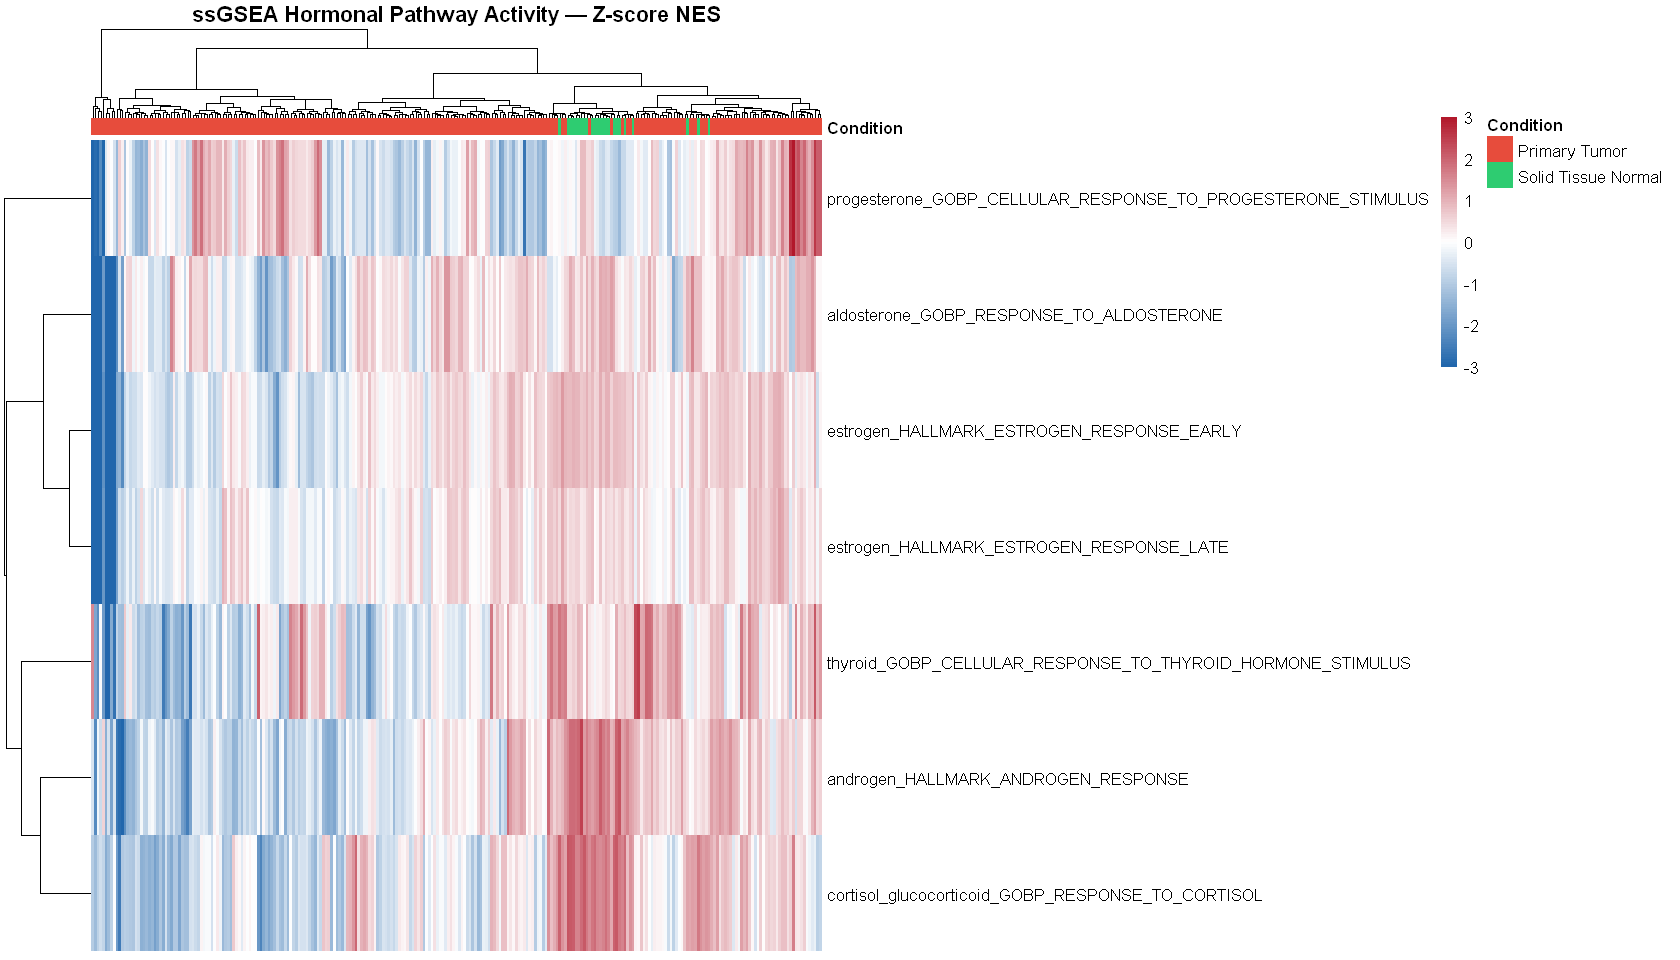

In [16]:
library(tidyverse)
library(pheatmap)

# ── Load  ssGSEA results ─────────────────────────────────────────────
# Each df: rows = samples, columns = pathways + sample_type column
ssgsea  <- read.csv("Output/ssGSEA/Output_ssGSEA_LUAD_TumorSamples&NATSamples_No_outlier.tsv",  row.names = 1, sep='\t')
rownames(ssgsea) <- gsub("\\.", "-", rownames(ssgsea))
ssgsea <- tibble::rownames_to_column(ssgsea, var = "samples.submitter_id")

# Add condition label
metadata<-read.csv('data/Metadata_Biospecimen_Clinical_TCGA2025.tsv', sep='\t')
ssgsea_meta <- ssgsea %>%
  inner_join(
    metadata %>% select(samples.submitter_id, samples.sample_type),
    by = "samples.submitter_id"
  )

sample_names <- ssgsea_meta$samples.submitter_id 
rownames(ssgsea_meta) <- sample_names

# ── Prepare matrix ─────────────────────────────────────────────────────────────
# Separate metadata from scores
meta <- ssgsea_meta %>% select(samples.sample_type)
mat  <- ssgsea_meta %>% select(-samples.sample_type, -samples.submitter_id)%>% as.matrix()  # samples × pathways

# Transpose to pathways × samples (pheatmap expects features on rows)
mat <- t(mat)

# ── Z-score per pathway (row-wise) ────────────────────────────────────────────
mat_z <- t(scale(t(mat)))  # scale() works column-wise, so double-transpose

# ── Annotation bar ────────────────────────────────────────────────────────────
ann_col <- data.frame(
  Condition = meta$samples.sample_type,
  row.names = rownames(meta)
)

ann_colors <- list(
  Condition = c(
    "Primary Tumor"       = "#E74C3C",
    "Solid Tissue Normal" = "#2ECC71"
  )
)

# ── Sort samples: Normal first, Tumor second ──────────────────────────────────
sample_order <- order(ann_col$Condition)
mat_z   <- mat_z[, sample_order]
ann_col <- ann_col[sample_order, , drop = FALSE]

# ── Plot heatmap ──────────────────────────────────────────────────────────────
#png("Output/ssgsea_heatmap_TumorNormal.png", width = 20, height = 10, units = "in", res = 150)
options(repr.plot.width = 14, repr.plot.height = 8)
pheatmap::pheatmap(
  mat_z,
  color             = colorRampPalette(c("#2166AC", "white", "#B2182B"))(100),
  breaks            = seq(-3, 3, length.out = 101),   # clip extreme z-scores
  annotation_col    = ann_col,
  annotation_colors = ann_colors,
  cluster_cols      =  ncol(mat_z) > 1,   # dendrogram on top
  cluster_rows      = nrow(mat_z) >1,   # dendrogram on left
  clustering_method = "ward.D2",
  show_colnames     = FALSE,  # too many samples to label
  show_rownames     = TRUE,
  fontsize_row      = 10,
  #cellheight        = 30,
  border_color      = NA,
  main              = "ssGSEA Hormonal Pathway Activity — Z-score NES",
  #filename          = "ssgsea_heatmap.png",
  width             = 100,
  height            =20
)
#dev.off()


## 6 Differential pathway activity — tumor vs. normal

For each pathway, we test whether ssGSEA scores differ 
significantly between tumor and normal samples using the **Mann-Whitney U test** 
(non-parametric, justified by the normality analysis in Section 2).

Multiple testing correction is applied using **Benjamini-Hochberg FDR**.




Total tests: 7
Significant after FDR correction: 6 (85.7%)
                                                       signature median_delta
W...1          cortisol_glucocorticoid_GOBP_RESPONSE_TO_CORTISOL   -4177.8745
W...2                        androgen_HALLMARK_ANDROGEN_RESPONSE    -837.6990
W...3                  estrogen_HALLMARK_ESTROGEN_RESPONSE_EARLY    -612.5077
W...4                   aldosterone_GOBP_RESPONSE_TO_ALDOSTERONE    -726.1874
W...5                   estrogen_HALLMARK_ESTROGEN_RESPONSE_LATE    -342.2182
W...6 thyroid_GOBP_CELLULAR_RESPONSE_TO_THYROID_HORMONE_STIMULUS    -377.6022
             rbc     pval_fdr
W...1 -0.9785714 1.826139e-14
W...2 -0.8857143 2.870027e-12
W...3 -0.7285714 9.143134e-09
W...4 -0.5078231 7.127391e-05
W...5 -0.4176871 1.034360e-03
W...6 -0.3438776 6.378005e-03


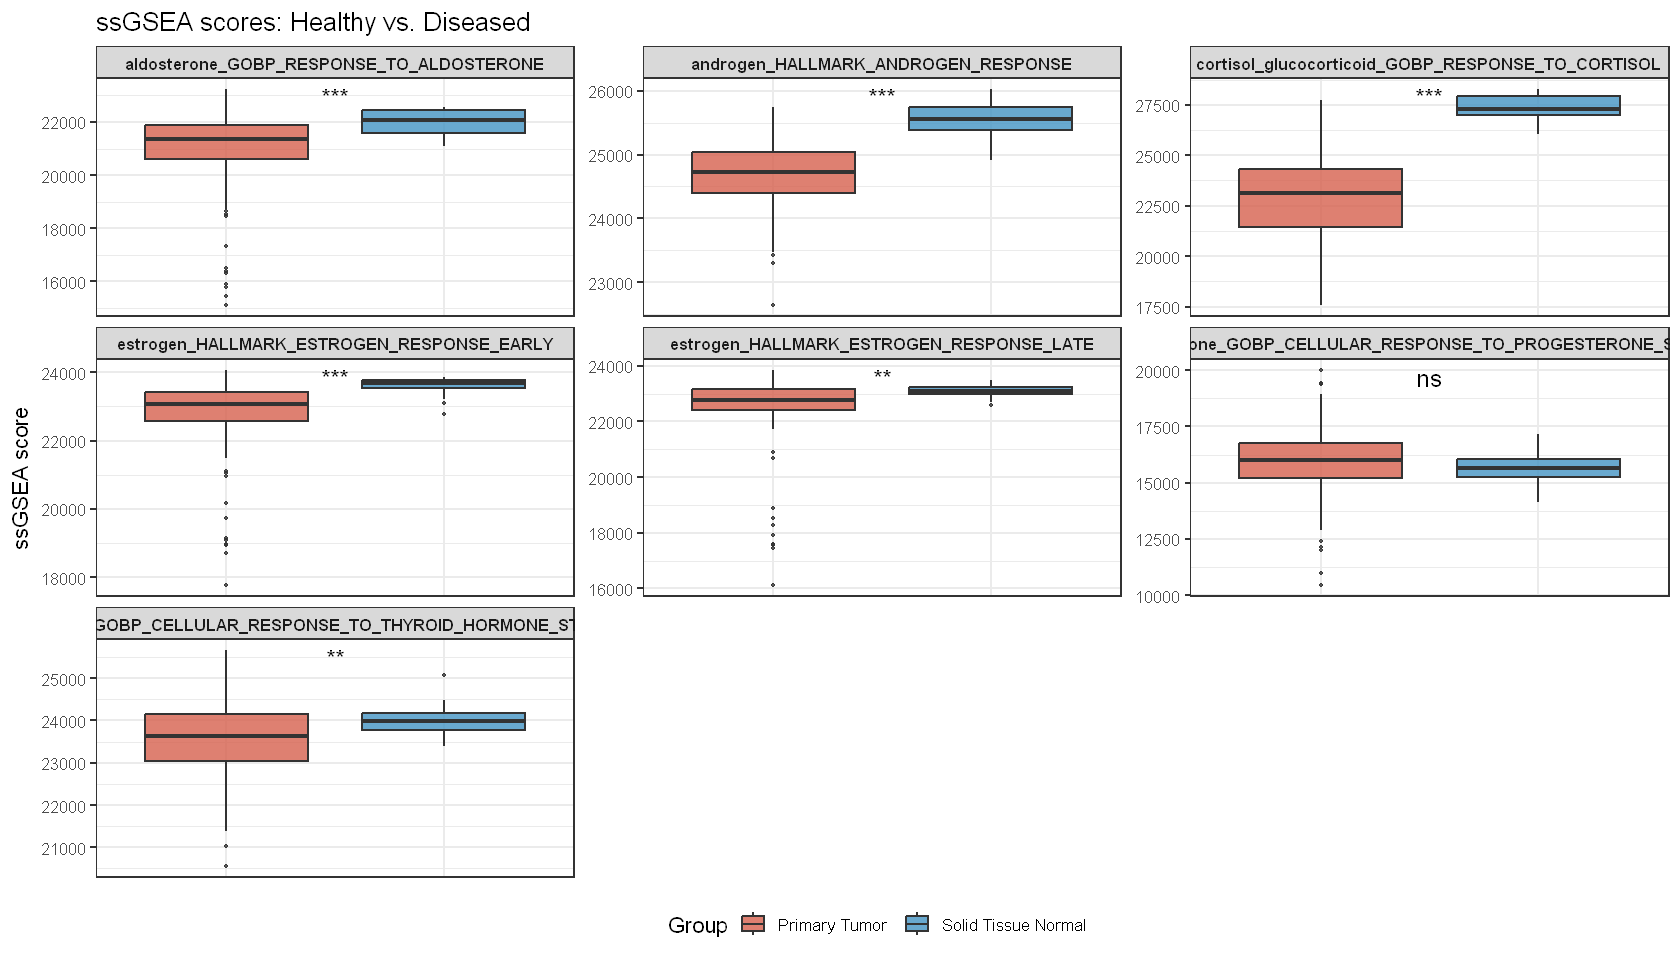

In [18]:
# ── Differential ssGSEA: healthy vs. diseased samples per signature ───────────

library(dplyr)
library(tidyr)
library(ggplot2)
metadata<-read.csv('data/Metadata_Biospecimen_Clinical_TCGA2025.tsv', sep='\t')
# ── Harmonise sample IDs: replace '.' with '-' in score matrix columns ─────
colnames(mat) <- gsub("\\.", "-", colnames(mat))

# ── Pivot score matrix to long format ──────────────────────────────────────
df<-as.data.frame(mat)
df2 <- tibble::rownames_to_column(df, var = "signature")


scores_long <- tidyr::pivot_longer(
  df2,
  cols      = -signature,
  names_to  = "samples.submitter_id",
  values_to = "score"
)

# ── Join with metadata to attach group labels ──────────────────────────────
scores_long <- scores_long %>%
  inner_join(
    metadata %>% select(samples.submitter_id, samples.sample_type),
    by = "samples.submitter_id"
  )

# ── Define the two groups to compare ───────────────────────────────────────
GROUP_A <- "Solid Tissue Normal"   # <-- edit to match your label
GROUP_B <- "Primary Tumor"         # <-- edit to match your label

scores_filtered <- scores_long %>%
  filter(samples.sample_type %in% c(GROUP_A, GROUP_B))

# ── Run Mann-Whitney U test per signature + FDR correction ─────────────────
signatures <- unique(scores_filtered$signature)

results <- lapply(signatures, function(sig) {

  dat <- scores_filtered %>% filter(signature == sig)

  vals_a <- dat %>% filter(samples.sample_type == GROUP_A) %>% pull(score) %>% na.omit()
  vals_b <- dat %>% filter(samples.sample_type == GROUP_B) %>% pull(score) %>% na.omit()

  # Skip signatures with too few observations in either group
  if (length(vals_a) < 5 || length(vals_b) < 5) return(NULL)

  test <- wilcox.test(vals_a, vals_b, alternative = "two.sided", exact = FALSE)

  # Effect size: rank-biserial correlation
  n1  <- length(vals_a)
  n2  <- length(vals_b)
  rbc <- 1 - (2 * test$statistic) / (n1 * n2)

  data.frame(
    signature    = sig,
    stat         = test$statistic,
    pval         = test$p.value,
    rbc          = as.numeric(rbc),
    median_delta = median(vals_b) - median(vals_a),   # Tumor - Normal
    n_a          = n1,
    n_b          = n2
  )
})
diff_df <- bind_rows(results)

# FDR correction (Benjamini-Hochberg) across all tests
diff_df$pval_fdr    <- p.adjust(diff_df$pval, method = "BH")
diff_df$significant <- diff_df$pval_fdr < 0.05

# ── Summary ────────────────────────────────────────────────────────────────
cat(sprintf("Total tests: %d\n", nrow(diff_df)))
cat(sprintf(
  "Significant after FDR correction: %d (%.1f%%)\n",
  sum(diff_df$significant),
  100 * mean(diff_df$significant)
))

print(
  diff_df %>%
    filter(significant) %>%
    arrange(pval_fdr) %>%
    select(signature, median_delta, rbc, pval_fdr) %>%
    head(15)
)

# ── Boxplot: one panel per signature ───────────────────────────────────────
# Add significance label for plot annotation
diff_df <- diff_df %>%
  mutate(sig_label = case_when(
    pval_fdr < 0.001 ~ "***",
    pval_fdr < 0.01  ~ "**",
    pval_fdr < 0.05  ~ "*",
    TRUE             ~ "ns"
  ))

# Merge significance labels back into the long data for faceting
plot_data <- scores_filtered %>%
  left_join(diff_df %>% select(signature, pval_fdr, sig_label), by = "signature")

ggplot(plot_data, aes(x = samples.sample_type, y = score, fill = samples.sample_type)) +

  geom_boxplot(outlier.size = 0.8, alpha = 0.8) +

  # Significance stars above each pair
  geom_text(
    data = diff_df,
    aes(x = 1.5, y = Inf, label = sig_label),
    inherit.aes = FALSE,
    vjust = 1.5, size = 5
  ) +

  facet_wrap(~ signature, scales = "free_y") +

  scale_fill_manual(values = c(
    "Solid Tissue Normal" = "#4393C3",
    "Primary Tumor"       = "#D6604D"
  )) +

  labs(
    title = "ssGSEA scores: Healthy vs. Diseased",
    x     = NULL,
    y     = "ssGSEA score",
    fill  = "Group"
  ) +

  theme_bw(base_size = 13) +
  theme(
    strip.text   = element_text(face = "bold"),
    axis.text.x  = element_blank(),
    axis.ticks.x = element_blank(),
    legend.position = "bottom"
  )


# Immune deconvolution

Understanding the **tumor immune microenvironment (TME)** is critical in modern oncology: 
the composition of infiltrating immune cells influences prognosis, response to immunotherapy, 
and overall tumor behavior.

In this notebook, I apply **CIBERSORT in absolute mode** to bulk RNA-seq data from 
**The Cancer Genome Atlas (TCGA)** across multiple tumor types. CIBERSORT uses a 
support vector regression approach to estimate the **absolute abundance** of 22 immune 
cell types (LM22 signature matrix) from gene expression profiles.

**Key methodological choices:**
- TPM-normalized input, consistent with CIBERSORT recommendations for RNA-seq data
- Quantile normalization **disabled** (as recommended for RNA-seq — QN is designed for microarrays)
- Absolute mode enabled to capture total immune infiltration, not just relative fractions
- 100 permutations for statistical significance estimation per sample

This pipeline generalizes to any cohort with bulk transcriptomic data and is directly 
applicable beyond oncology — e.g., autoimmune disease, infection, or aging studies.

## 1. Library Loading

- **immunedeconv**: unified R interface to multiple deconvolution methods
- **dplyr**: efficient data manipulation


Note: CIBERSORT requires external files (`CIBERSORT.R` and `LM22.txt`) due to 
licensing restrictions — these must be obtained directly from the Bindley Biosciences Center 
and are not redistributed here.

In [ ]:

library(dplyr)
library(immunedeconv)

## 2. TCGA Pan-Cancer Cohort Index

We load the same cancer type metadata used in the ssGSEA notebook, ensuring 
consistency across analyses. The loop will attempt deconvolution for every cohort 
for which a TPM expression file exists, making the pipeline fully scalable.

In [68]:
# ── Load cancer metadata ───────────────────────────────────────────────────
cancer_df=read.csv('data/PANCANCER_acronym_npatients.tsv', sep='\t')
cancers<-c(cancer_df$Cancer_acronym)
head(cancer_df)

,Cancer_acronym,N_of_patients
,<chr>,<int>
1,UCEC,537
2,CHOL,36
3,TGCT,133
4,PAAD,177
5,GBM,143
6,SKCM,103


## 3. CIBERSORT Configuration

Before running the loop, we define all CIBERSORT parameters once — avoiding 
redundant assignments inside the loop and making it easy to adjust the analysis globally.

Key parameters:
- **`perm = 100`**: number of permutations used to compute a p-value per sample; 
  higher values increase precision but runtime scales linearly
- **`QN = FALSE`**: quantile normalization is disabled — it is appropriate for microarray 
  data but distorts RNA-seq distributions
- **`absolute = TRUE`**: absolute mode estimates total immune content per sample, 
  not just cell type proportions; this is more informative for cross-tumor comparisons
- **`abs_method = "sig.score"`**: scales cell fractions by the ratio of median 
  signature expression to median mixture expression, providing a biologically 
  interpretable absolute score

In [ ]:
set_cibersort_binary("CIBERSORT.R")
set_cibersort_mat("LM22.txt")
source("CIBERSORT.R")
sig_matrix        <- "LM22.txt"
cibersort_perm    <- 100
cibersort_qn      <- FALSE   # QN not recommended for RNA-seq
cibersort_abs     <- TRUE    # absolute mode for cross-sample comparability
cibersort_abs_method <- "sig.score"

## 4. Pan-Cancer Deconvolution Loop

For each available TCGA cohort we:

1. Load the TPM expression matrix
2. Format it with gene names as row identifiers (required by CIBERSORT)
3. Run CIBERSORT with the pre-defined parameters
4. Write the output — one row per sample, one column per immune cell type — to disk

The output files feed directly into downstream comparative analyses 
(e.g., correlating immune infiltration with circadian rhythm scores from the ssGSEA notebook).

In [ ]:
# ── Pan-cancer deconvolution loop ─────────────────────────────────────────
for (cancer in cancers) {
  message("Processing: ", cancer)
  
  input_file <- paste0("data/TPM/NO_outlier/TCGA-", cancer, "_2025_TumorSamples&NATSamples_TPM_No_outlier.tsv")
  
  if (!file.exists(input_file)) {
    message("  File not found, skipping.")
    next
  }
  
  counts_raw <- read.csv(input_file, sep = "\t")
  counts     <- data.frame(counts_raw[, -1], row.names = counts_raw[, 1])
  
  message("  Matrix dimensions: ", nrow(counts), " genes x ", ncol(counts), " samples")
  
  res_ciber <- CIBERSORT(
    sig_matrix,
    counts,
    perm       = cibersort_perm,
    QN         = cibersort_qn,
    absolute   = cibersort_abs,
    abs_method = cibersort_abs_method
  )
  
  out_file <- paste0(
    "Ouput/Deconvolution/TCGA-", cancer,
    "TumorSamples&NATSamples_No_outlier_TPM_CibersortAbsModeDeconv.tsv"
  )
  write.table(res_ciber, out_file, sep = "\t")
  
  message("  Saved: ", out_file)
}

## 5 Differential immune cells proportions — tumor vs. normal

For each immune cell type, we test whether cell proportions differ 
significantly between tumor and normal samples using the **Mann-Whitney U test** 
(non-parametric, justified by the normality analysis in Section 2).

Multiple testing correction is applied using **Benjamini-Hochberg FDR**.




Total tests: 22
Significant after FDR correction: NA (NA%)
                            cell_type median_delta        rbc     pval_fdr
W...1                      Eosinophil  -0.03002280 -0.6076248 3.887150e-10
W...2       T cell regulatory (Tregs)   0.15884927  0.8009447 9.336160e-10
W...3                        Monocyte  -0.21248032 -0.7611336 3.494050e-09
W...4                 NK cell resting  -0.18105705 -0.6616059 3.457232e-08
W...5        T cell follicular helper   0.13896351  0.6990553 6.530996e-08
W...6                      Neutrophil  -0.12373826 -0.6656545 2.509246e-07
W...7                   B cell plasma   0.18633195  0.6450742 5.519354e-07
W...8                   Macrophage M0  -0.39625190 -0.5204116 6.785092e-05
W...9                   Macrophage M2  -0.24385214 -0.5060729 1.003464e-04
W...10   T cell CD4+ memory activated   0.05417966  0.4910594 1.103217e-04
W...11            Mast cell activated  -0.22942226 -0.4416329 6.778365e-04
W...12                  Macrophage M1   0

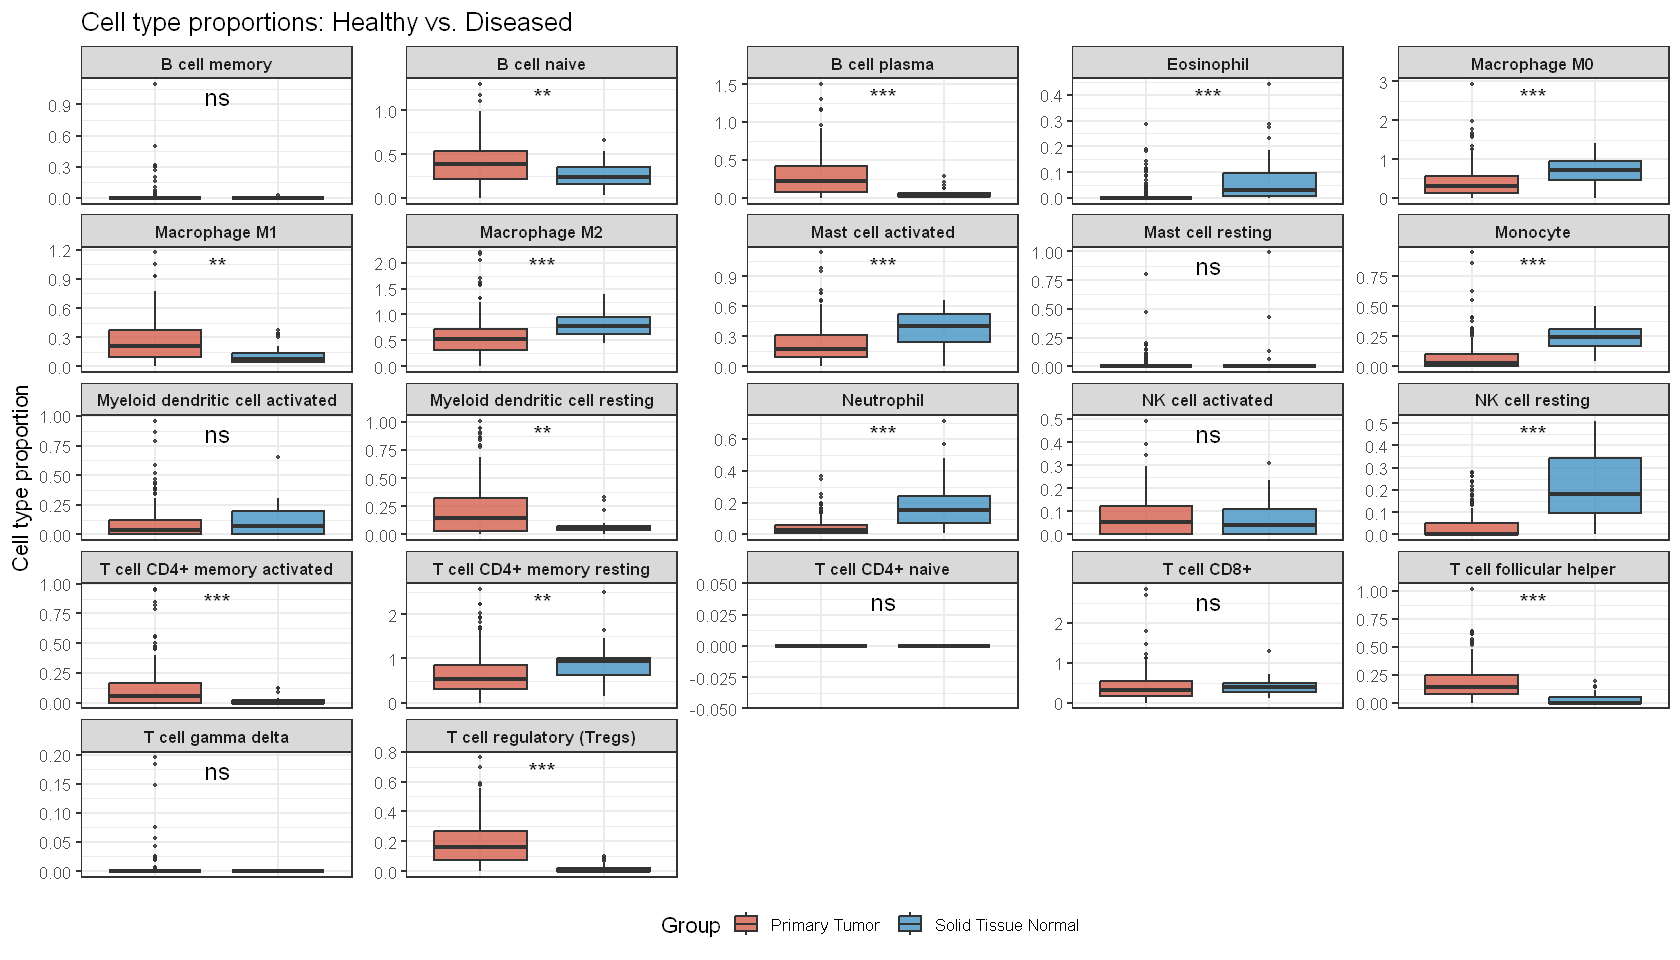

In [20]:
# ── Differential ssGSEA: healthy vs. diseased samples per signature ───────────

library(dplyr)
library(tidyr)
library(ggplot2)
metadata<-read.csv('data/Metadata_Biospecimen_Clinical_TCGA2025.tsv', sep='\t')
deconvolution_df<-read.csv('Output/Deconvolution/TCGA-LUAD_TumorSamples&NATSamples_No_outlier_TPM_CibersortAbsModeDeconv.tsv', sep='\t')

# ── Differential deconvolution: healthy vs. diseased samples per cell type ────

library(dplyr)
library(tidyr)
library(ggplot2)

# ── Harmonise sample IDs: replace '.' with '-' in columns ────────────────────
colnames(deconvolution_df) <- gsub("\\.", "-", colnames(deconvolution_df))

# ── Pivot deconvolution matrix to long format ─────────────────────────────────
# cell types are on rows → rownames_to_column as "cell_type"
df2  <- as.data.frame(deconvolution_df)

scores_long <- tidyr::pivot_longer(
  df2,
  cols      = -cell_type,
  names_to  = "samples.submitter_id",
  values_to = "proportion"             # renamed from 'score' to 'proportion'
)

# ── Join with metadata to attach group labels ─────────────────────────────────
scores_long <- scores_long %>%
  inner_join(
    metadata %>% select(samples.submitter_id, samples.sample_type),
    by = "samples.submitter_id"
  )

# ── Define the two groups to compare ─────────────────────────────────────────
GROUP_A <- "Solid Tissue Normal"
GROUP_B <- "Primary Tumor"

scores_filtered <- scores_long %>%
  filter(samples.sample_type %in% c(GROUP_A, GROUP_B))

# ── Run Mann-Whitney U test per cell type + FDR correction ───────────────────
cell_types <- unique(scores_filtered$cell_type)

results <- lapply(cell_types, function(ct) {

  dat <- scores_filtered %>% filter(cell_type == ct)

  vals_a <- dat %>% filter(samples.sample_type == GROUP_A) %>% pull(proportion) %>% na.omit()
  vals_b <- dat %>% filter(samples.sample_type == GROUP_B) %>% pull(proportion) %>% na.omit()

  # Skip cell types with too few observations in either group
  if (length(vals_a) < 5 || length(vals_b) < 5) return(NULL)

  test <- wilcox.test(vals_a, vals_b, alternative = "two.sided", exact = FALSE)

  # Effect size: rank-biserial correlation
  n1  <- length(vals_a)
  n2  <- length(vals_b)
  rbc <- 1 - (2 * test$statistic) / (n1 * n2)

  data.frame(
    cell_type    = ct,
    stat         = test$statistic,
    pval         = test$p.value,
    rbc          = as.numeric(rbc),
    median_delta = median(vals_b) - median(vals_a),   # Tumor - Normal
    n_a          = n1,
    n_b          = n2
  )
})

diff_df <- bind_rows(results)

# FDR correction (Benjamini-Hochberg) across all tests
diff_df$pval_fdr    <- p.adjust(diff_df$pval, method = "BH")
diff_df$significant <- diff_df$pval_fdr < 0.05

# ── Summary ───────────────────────────────────────────────────────────────────
cat(sprintf("Total tests: %d\n", nrow(diff_df)))
cat(sprintf(
  "Significant after FDR correction: %d (%.1f%%)\n",
  sum(diff_df$significant),
  100 * mean(diff_df$significant)
))

print(
  diff_df %>%
    filter(significant) %>%
    arrange(pval_fdr) %>%
    select(cell_type, median_delta, rbc, pval_fdr) %>%
    head(15)
)

# ── Boxplot: one panel per cell type ─────────────────────────────────────────
diff_df <- diff_df %>%
  mutate(sig_label = case_when(
    pval_fdr < 0.001 ~ "***",
    pval_fdr < 0.01  ~ "**",
    pval_fdr < 0.05  ~ "*",
    TRUE             ~ "ns"
  ))

# Merge significance labels back into long data for faceting
plot_data <- scores_filtered %>%
  left_join(diff_df %>% select(cell_type, pval_fdr, sig_label), by = "cell_type")

ggplot(plot_data, aes(x = samples.sample_type, y = proportion, fill = samples.sample_type)) +

  geom_boxplot(outlier.size = 0.8, alpha = 0.8) +

  # Significance stars above each pair
  geom_text(
    data = diff_df,
    aes(x = 1.5, y = Inf, label = sig_label),
    inherit.aes = FALSE,
    vjust = 1.5, size = 5
  ) +

  facet_wrap(~ cell_type, scales = "free_y") +

  scale_fill_manual(values = c(
    "Solid Tissue Normal" = "#4393C3",
    "Primary Tumor"       = "#D6604D"
  )) +

  labs(
    title = "Cell type proportions: Healthy vs. Diseased",
    x     = NULL,
    y     = "Cell type proportion",
    fill  = "Group"
  ) +

  theme_bw(base_size = 13) +
  theme(
    strip.text      = element_text(face = "bold"),
    axis.text.x     = element_blank(),
    axis.ticks.x    = element_blank(),
    legend.position = "bottom"
  )


## 6. Summary & decisions for downstream analysis

| Observation | Decision |
|---|---|
| Distribution of ssGSEA score are significantly (p-value<=0.05) different between normal and tumor samples| Biological signal is strong |
| Immune cell proportions are statistically abundant between normal and tumor samples | Biological signal is strong |


---
*Next: `03_hormone_immune_correlation.ipynb` — Spearman correlation will be computed between hormone signatures and immune cell types proportions*
